# Classification of Toy Model trajectories

## 1. Using the  method from Costa et. al.


[1] Costa, Antonio C., Tosif Ahamed, David Jordan, and Greg J. Stephens. “A Markovian Dynamics for Caenorhabditis Elegans Behavior across Scales.” Proceedings of the National Academy of Sciences 121, no. 32 (2024): e2318805121. https://doi.org/10.1073/pnas.2318805121.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import plotly.express as px
import matplotlib.gridspec as gridspec

import seaborn as sns
import pickle

import sys
sys.path.append('../../')
from mpl_toolkits.axes_grid1 import make_axes_locatable
import src.viz
from src.embedding_position import EmbeddingPosition

def average_curvature_angle(traj: np.ndarray, degrees: bool = False) -> float:
    """
    Compute the average curvature angle along a 3D trajectory.

    Parameters
    ----------
    traj : (T, 3) ndarray
        Sequence of 3D points.
    degrees : bool, optional
        If True, return the average angle in degrees. Otherwise radians.

    Returns
    -------
    float
        Average curvature angle. NaN if fewer than one valid interior angle.

    Notes
    -----
    - Angle at index i is the angle between segments (r[i] - r[i-1]) and (r[i+1] - r[i]).
    - Zero-length steps are skipped.
    """
    traj = np.asarray(traj)
    if traj.ndim != 2 or traj.shape[1] != 3:
        raise ValueError("traj must have shape (T, 3)")
    if traj.shape[0] < 3:
        return np.nan

    # Segment vectors between consecutive points
    seg = np.diff(traj, axis=0)                # shape (T-1, 3)
    seg_norm = np.linalg.norm(seg, axis=1)     # shape (T-1,)

    # Pairs of consecutive segments define interior angles
    v0 = seg[:-1]
    v1 = seg[1:]
    n0 = seg_norm[:-1]
    n1 = seg_norm[1:]

    # Mask out angles involving any zero-length segment
    eps = 1e-12
    mask = (n0 > eps) & (n1 > eps)
    if not np.any(mask):
        return np.nan

    v0 = v0[mask]
    v1 = v1[mask]
    n0 = n0[mask]
    n1 = n1[mask]

    # Cosine of angles with numerical safety
    cos_theta = np.einsum('ij,ij->i', v0, v1) / (n0 * n1)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)

    angles = np.arccos(cos_theta)  # radians
    avg = angles.mean()
    return np.degrees(avg) if degrees else avg


In [22]:
names = ['persistent_straight','stereotypes2','stereotypes4','straight_helix']
dfs = list()
for name in names:
    dfs.append(pd.read_parquet('../../data/toy_model/interim/phases_'+name+'.parquet'))

In [28]:
embs = list()
ks = [5,10,10,10]
ncs = [10,100,100,100]
for df in dfs:
    embs.append(EmbeddingPosition(df,columns=[],columns_translated=['x','y','z'],ID_NAME='label'))
for k,emb in zip(ks,embs):
    emb.make_embedding(K=k)
for nc,emb in zip(ncs,embs):
    emb.make_cluster(n_clusters=nc)

names = ['persistent_straight','stereotypes2','stereotypes4','straight_helix']
data,indices = list(),list()
embs,mkvs= list(),list()
cluster_centers=list()
for name in names:
    try:
        indices.append(np.load('../../data/toy_model/processed/umap_indices_'+name+'.npy'))
    except:
        indices = np.arange(0,data.__len__(),1)
    with open('../../data/toy_model/processed/embedding_'+name+'.pkl', "rb") as f:
        embs.append(pickle.load(f))
    with open('../../data/toy_model/processed/markov_'+name+'.pkl', "rb") as f:
        mkvs.append(pickle.load(f))

for emb in embs:
    print('----------------------')
    print(emb.K)
    print(emb.n_clusters)

In [6]:
# recompute umap :
data = list()
for emb in embs:
    data.append(emb.fit_umap())

/mnt/hcleroy/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [29]:
for mkv in mkvs:
    mkv.tau = 10
    mkv.make_transition_matrix()
    mkv.compute_spectrum()
    mkv.reversibilized_matrix()
    mkv.compute_tr_spectrum()

In [12]:
data[0][0]

array([[-0.06478969,  1.5125139 ],
       [ 0.6605024 ,  0.64061004],
       [ 0.20841585,  0.22686821],
       ...,
       [-2.7687635 ,  1.4137375 ],
       [ 1.4042801 , -0.32219723],
       [ 0.9488243 , -1.478189  ]], dtype=float32)

/mnt/hcleroy/anaconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/mnt/hcleroy/anaconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


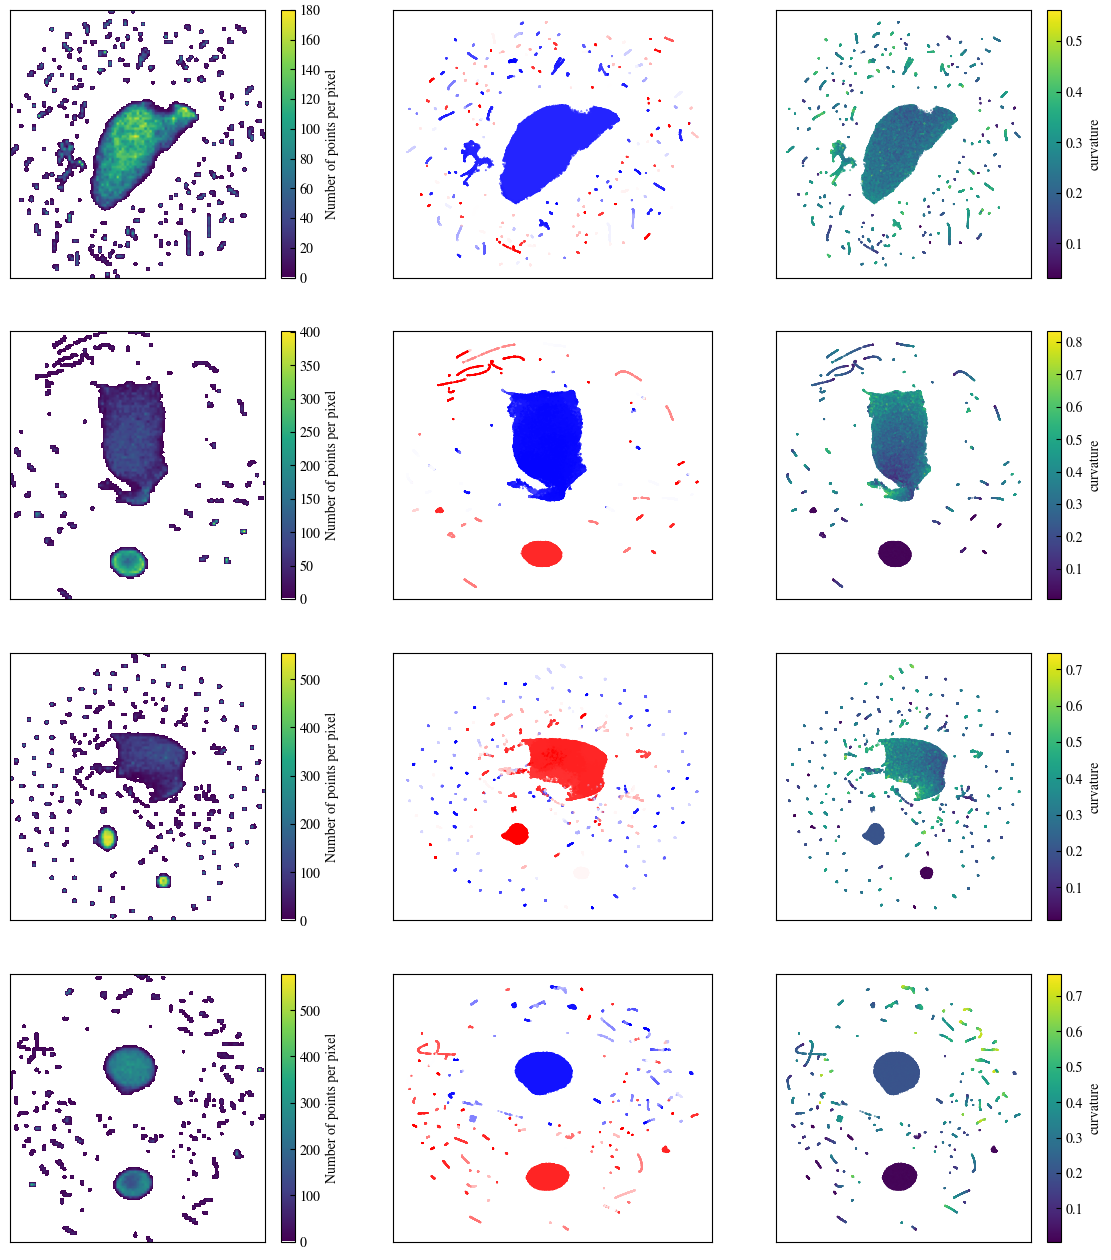

In [15]:

fig,ax = plt.subplots(ncols=3,nrows = embs.__len__(), figsize=(14,4*embs.__len__()),subplot_kw={'projection':'scatter_density'})


for i in range(embs.__len__()):
    curvature = np.array([average_curvature_angle(traj.reshape(-1,3)) for traj in embs[i].flatten_embedding_matrix])



    src.viz.use_mpl_scatter_density(fig,data[i][0][:,0],data[i][0][:,1],ax=ax[i,0],dpi=50)
    ax2 = ax[i,2].scatter(data[i][0][:,0],data[i][0][:,1],c=curvature,s=0.1,rasterized=True)#embs[i].labels,s=0.1)
    ax[i,1].scatter(data[i][0][:, 0],data[i][0][:, 1],c = mkvs[i].tr_slow_modes[:,-1][mkvs[i].labels],s=0.1,cmap='bwr',rasterized=True)
    fig.colorbar(ax2, label='curvature')

    for j in range(3):
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

theshold based on max of the min of both curves : -0.03
theshold based on max of the min of both curves : -0.06
theshold based on max of the min of both curves : -0.00
theshold based on max of the min of both curves : 0.10


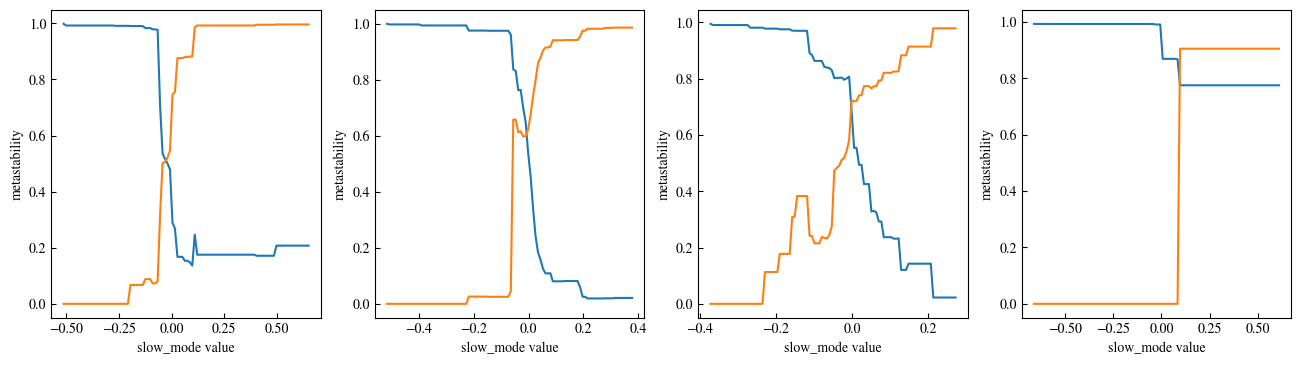

In [18]:
fig = plt.figure(figsize=(16, 4))
gs = gridspec.GridSpec(1, 4, height_ratios=[1], width_ratios=[1,1,1,1])
ax = list()
for i in range(4):
    ax.append(fig.add_subplot(gs[:,i]))

for i in range(4):
    mkv = mkvs[i]
    mkv.compute_metastability(time_reversed=True)
    threshold1 = mkv.thresholds[np.argmax([min(a,b) for a,b in zip(mkv.meta_in,mkv.meta_out)])]
    print(f"theshold based on max of the min of both curves : {threshold1:.2f}")
    #threshold1 = - 0.00
    ax[i].plot(mkv.thresholds,mkv.meta_in)
    ax[i].plot(mkv.thresholds,mkv.meta_out)
    #ax[i].plot([threshold1,threshold1],[0,1])
    ax[i].set_xlabel('slow_mode value')
    ax[i].set_ylabel('metastability')
    cluster_percent = np.array([np.argwhere(mkv.slow_mode>threshold)[:,0].__len__() for threshold in mkv.thresholds])/mkv.slow_mode.__len__()
    #ax[3].plot(mkv.thresholds,cluster_percent )
    #ax[3].set_xlabel('slow_mode value')
    #ax[3].set_ylabel('% clust in subset')

#data_percent = np.array([sum([labels_counting[w] for w in np.where(mkv.slow_mode>threshold)[0]]) for threshold in mkv.thresholds])/emb.labels.shape[0]
#ax11.plot(mkv.thresholds, data_percent)
#ax11.set_xlabel('slow_mode value')
#ax11.set_ylabel('% data in subset')

